### Carga Archivos y Libreria


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
%matplotlib inline
plt.style.use('seaborn')
sns.set_palette("husl")
train_data = pd.read_csv('titanic/train.csv')[['Survived','Pclass','Sex','Age','SibSp','Parch','Ticket','Fare','Embarked']]

def extract_ticket_prefix(ticket):
    parts = ticket.replace('.', '').replace('/', '').split()
    if len(parts) > 1:
        return parts[0]
    else:
        return 'NONE'


train_data['TicketPrefix'] = train_data['Ticket'].apply(extract_ticket_prefix)
train_data.drop(columns=['Ticket'], inplace=True)


/var/folders/cv/gdb475fx4q9by26c926zrqmw0000gn/T/ipykernel_52882/1630281424.py:23: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


### Analisis Univariado

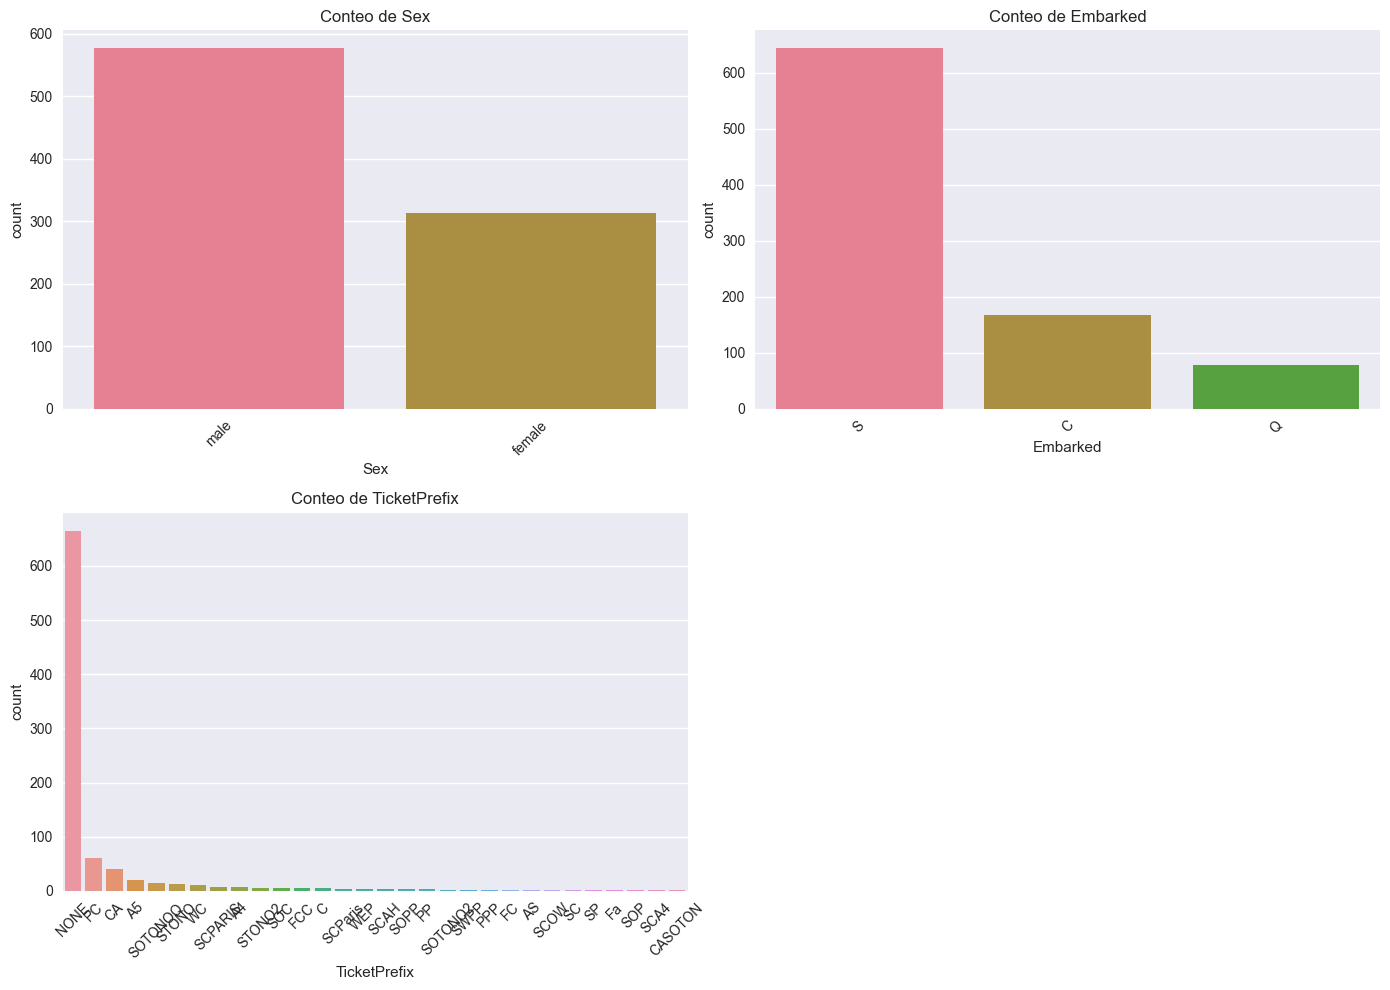

/Users/sightes/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sightes/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sightes/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sightes/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

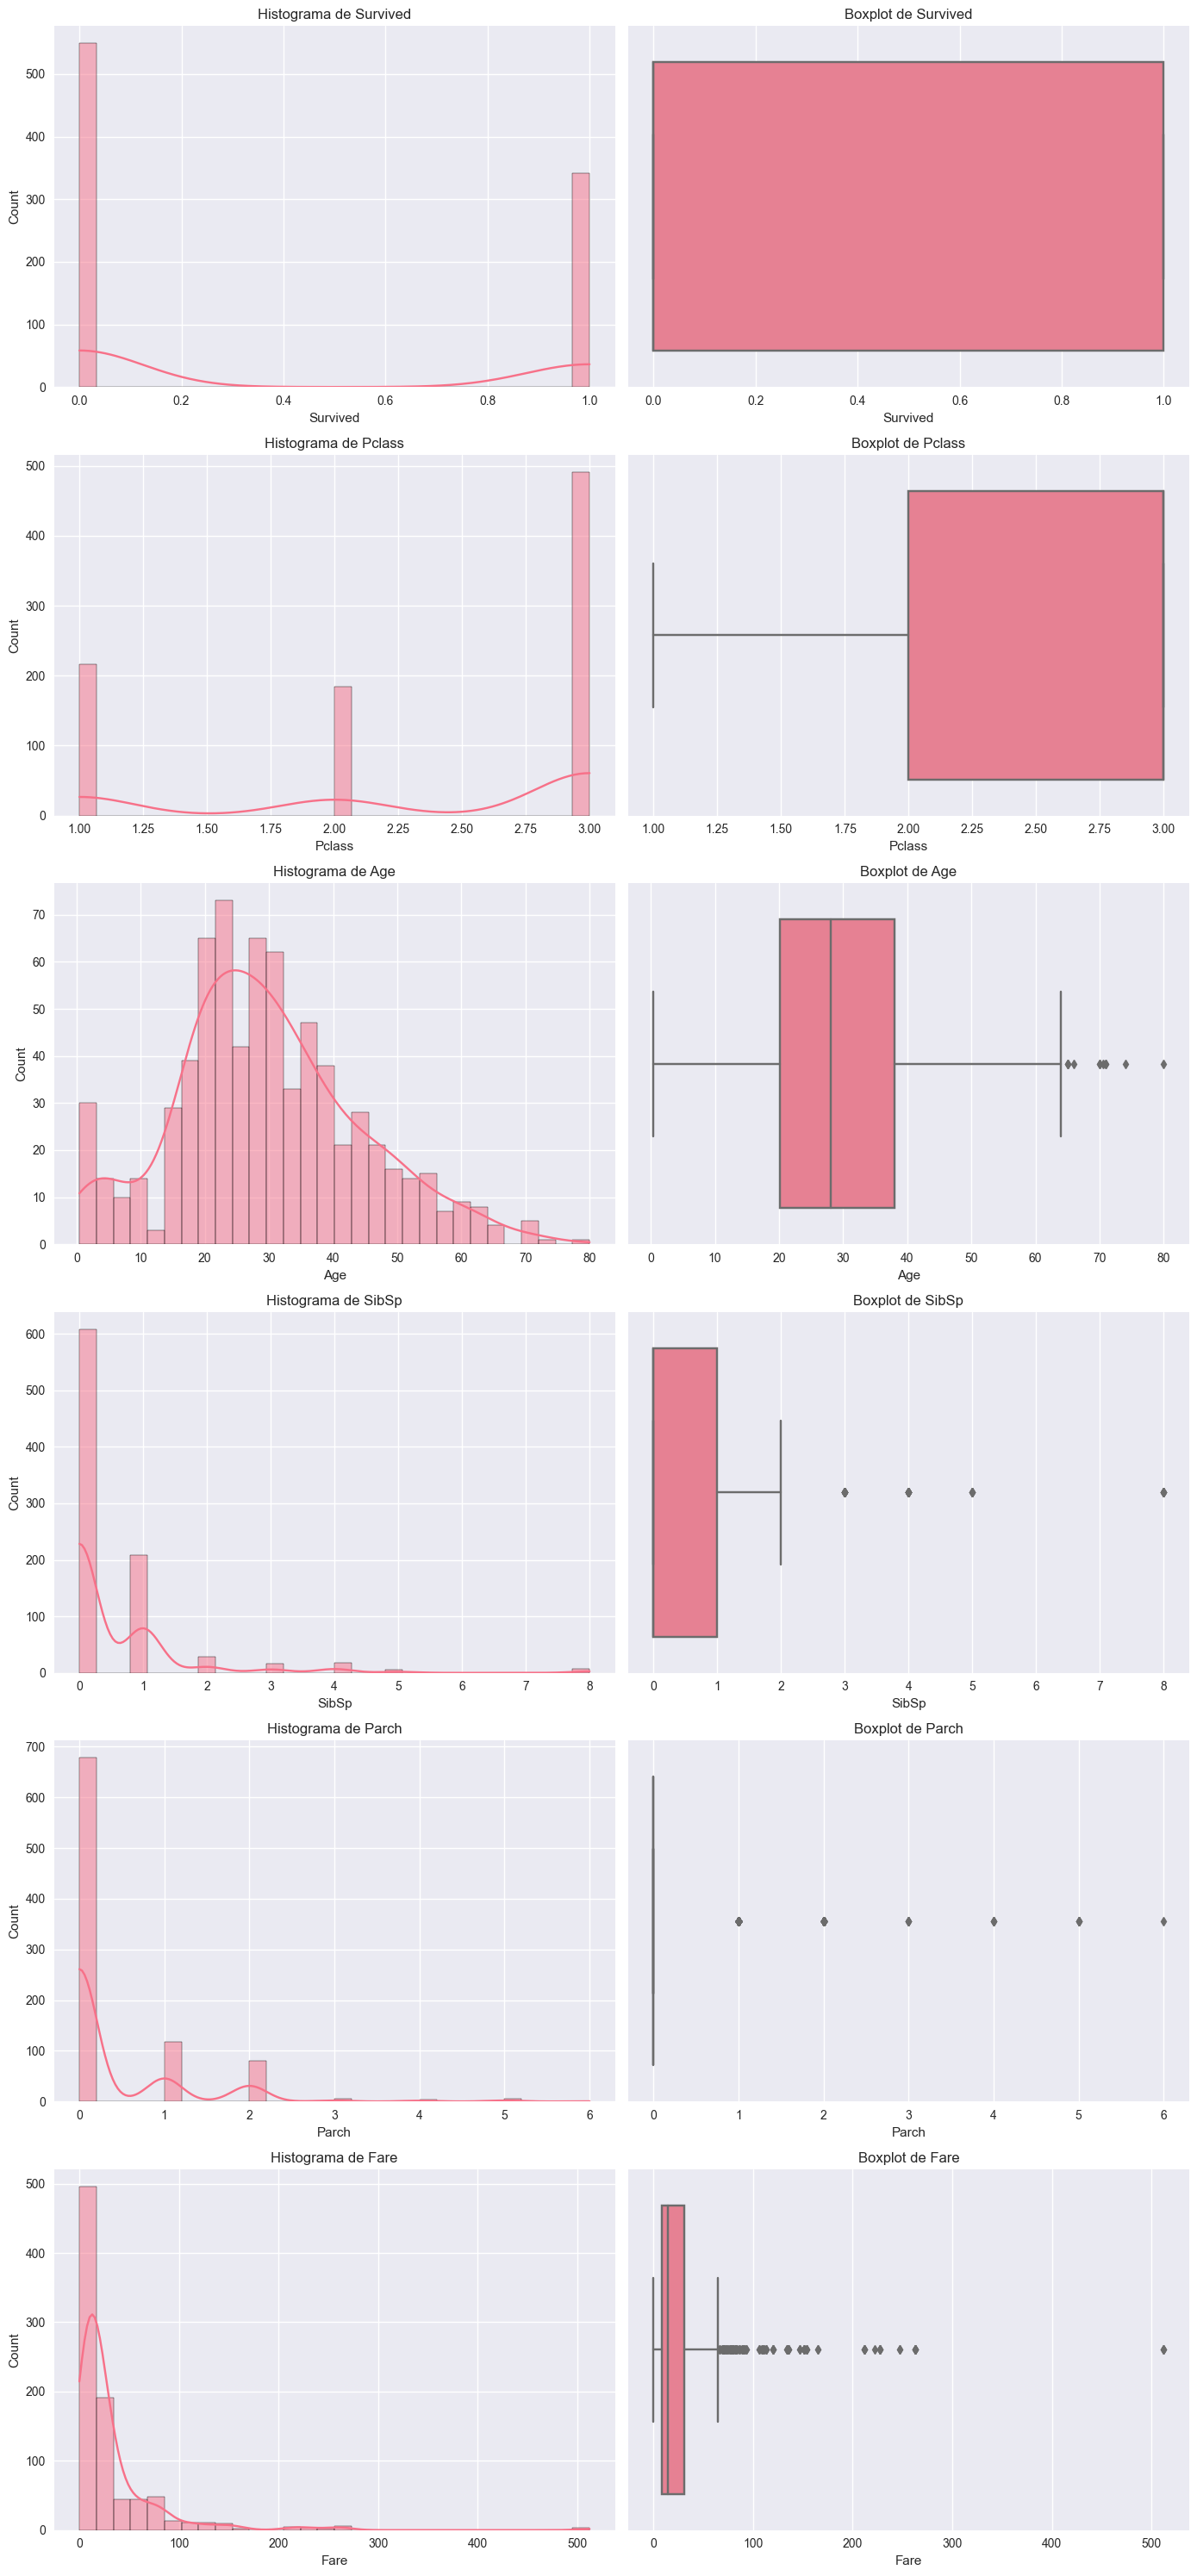

In [ ]:
def univariate_analysis(df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import math
    categorical_vars = df.select_dtypes(include=['object', 'category', 'bool']).columns
    numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns
    n_cat = len(categorical_vars)
    if n_cat > 0:
        ncols = 2
        nrows = math.ceil(n_cat / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
        axes = axes.flatten()
        for i, col in enumerate(categorical_vars):
            sns.countplot(x=col, data=df, order=df[col].value_counts().index, ax=axes[i])
            axes[i].set_title(f'Conteo de {col}')
            axes[i].tick_params(axis='x', rotation=45)
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])  # eliminar subplots vacíos
        plt.tight_layout()
        plt.show()
    n_num = len(numerical_vars)
    if n_num > 0:
        fig, axes = plt.subplots(n_num, 2, figsize=(14, 5 * n_num))
        for i, col in enumerate(numerical_vars):
            sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i, 0])
            axes[i, 0].set_title(f'Histograma de {col}')
            sns.boxplot(x=df[col], ax=axes[i, 1])
            axes[i, 1].set_title(f'Boxplot de {col}')
        plt.tight_layout()
        plt.show()
univariate_analysis(train_data)

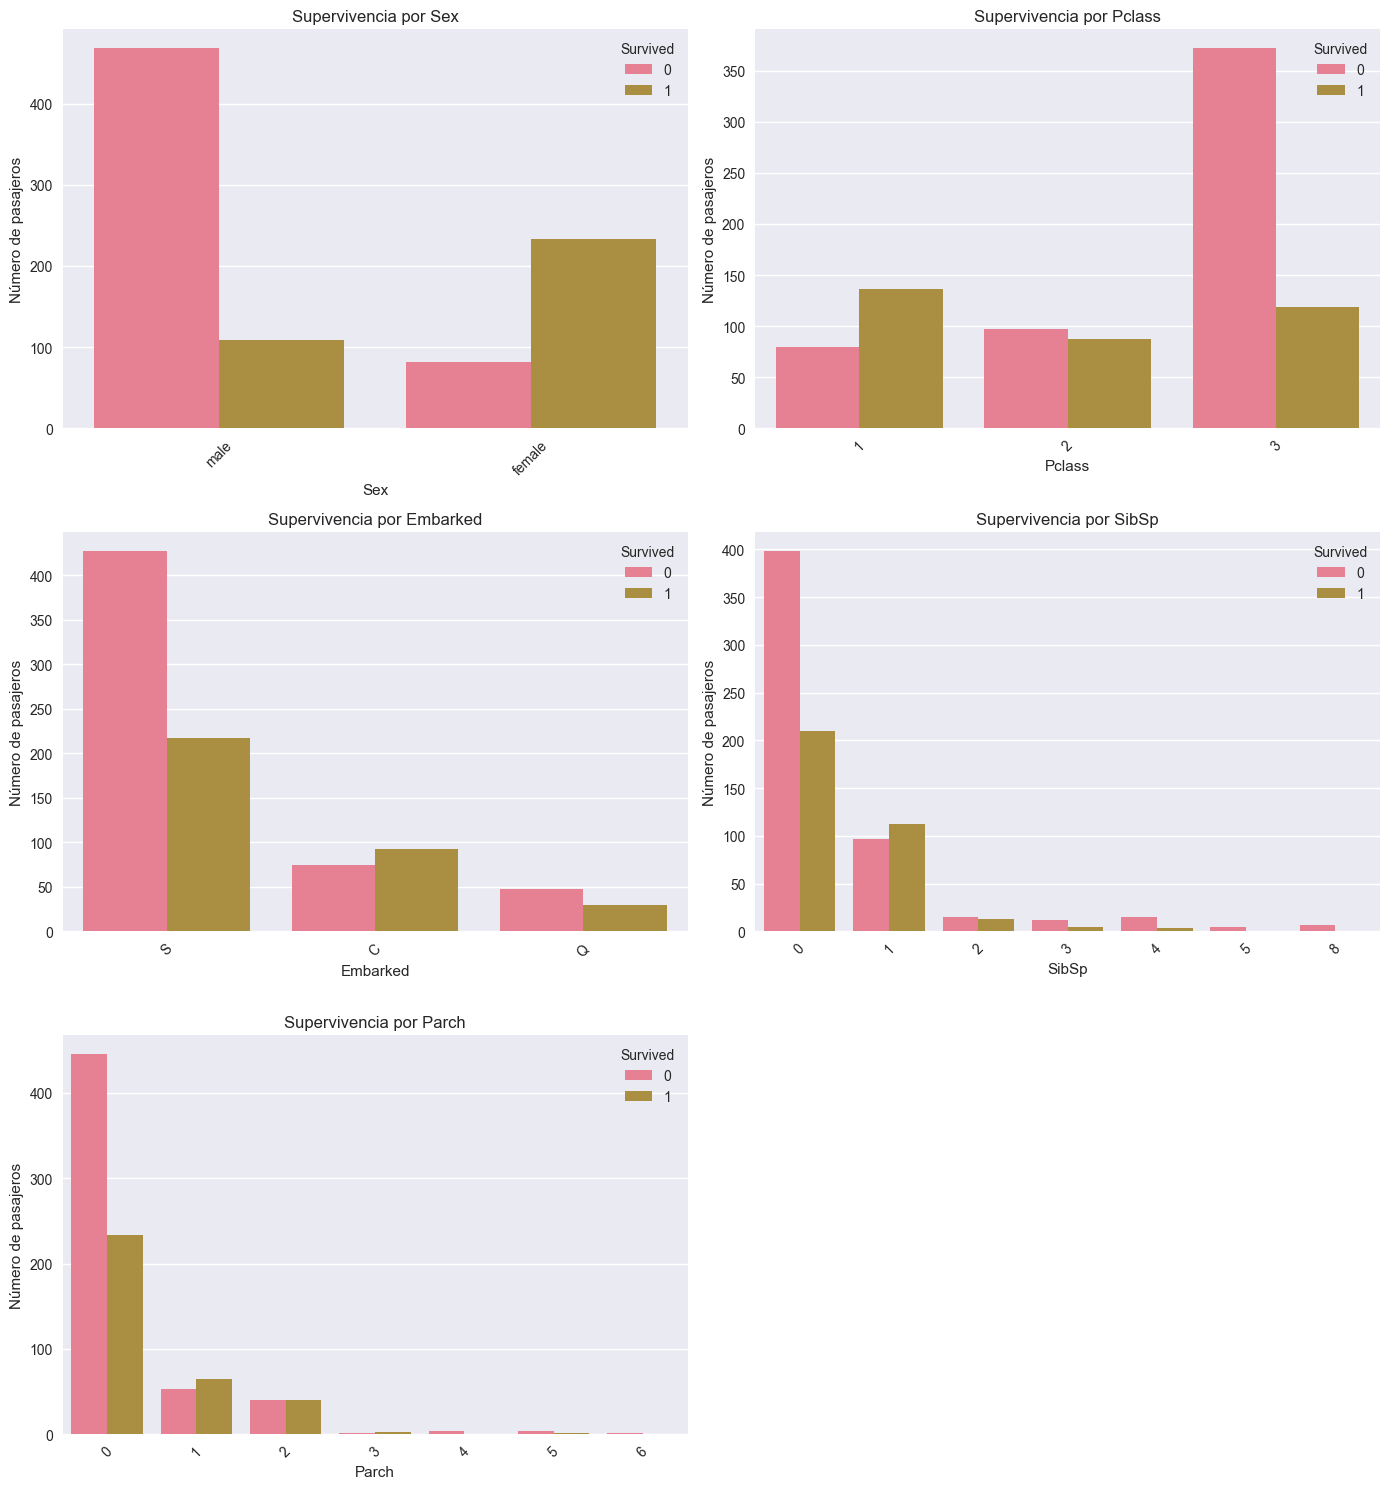

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_survival_by_features(df, features, target='Survived'):
    n = len(features)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows))
    axes = axes.flatten()
    for i, feature in enumerate(features):
        if df[feature].dtype in ['object', 'category', 'bool'] or df[feature].nunique() < 10:
            sns.countplot(x=feature, hue=target, data=df, ax=axes[i])
            axes[i].set_title(f'Supervivencia por {feature}')
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('Número de pasajeros')
            axes[i].tick_params(axis='x', rotation=45)
        else:
            sns.histplot(data=df, x=feature, hue=target, multiple='stack', ax=axes[i], bins=range(int(df[feature].max()) + 2))
            axes[i].set_title(f'Supervivencia por {feature}')
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('Número de pasajeros')
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])  # elimina subplots vacíos
    plt.tight_layout()
    plt.show()
features_to_plot = ['Sex', 'Pclass', 'Embarked', 'SibSp', 'Parch']
plot_survival_by_features(train_data, features_to_plot)

### Preprocesamiento Data

In [96]:
# Función de preprocesamiento
def preprocess_data(df):
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    le_sex = LabelEncoder()
    df['Sex'] = le_sex.fit_transform(df['Sex'])
    le_emb = LabelEncoder()
    df['Embarked'] = le_emb.fit_transform(df['Embarked'])
    return df,le_sex,le_emb
# Preparar datos
X,le_sex,le_emb  = preprocess_data(train_data)
y = X['Survived']
X = X[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']]

scaler = StandardScaler()


In [97]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    return df_clean[columns]  
numerical_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
X.loc[:, numerical_cols] = remove_outliers_iqr(X, numerical_cols)
X_scaled = scaler.fit_transform(X)

/var/folders/cv/gdb475fx4q9by26c926zrqmw0000gn/T/ipykernel_52882/1215703707.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.  1.  0.  1.  0.  0.  0.  2.5 0.  1.  1.  0.  0.  1.  0.  0.  2.5 0.
 1.  0.  0.  0.  0.  0.  2.5 1.  0.  2.5 0.  0.  0.  1.  0.  0.  1.  1.
 0.  0.  2.  1.  1.  1.  0.  1.  0.  0.  1.  0.  2.  1.  2.5 0.  1.  1.
 0.  0.  0.  0.  1.  2.5 0.  0.  1.  2.5 0.  1.  0.  0.  2.5 2.  0.  2.5
 0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  2.5 1.  0.  2.5 0.
 0.  0.  1.  1.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  2.  0.  0.  0.
 0.  1.  0.  1.  0.  1.  0.  0.  0.  1.  0.  2.5 2.  0.  1.  0.  0.  1.
 0.  0.  1.  0.  0.  0.  1.  1.  0.  0.  0.  1.  0.  0.  0.  0.  1.  0.
 0.  1.  0.  2.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  2.5 0.  0.
 0.  0.  2.5 0.  0.  1.  0.  0.  0.  2.5 1.  0.  0.  1.  2.5 0.  0.  0.
 2.5 0.  2.5 2.  0.  0.  1.  0.  1.  0.  0.  0.  1.  1.  0.  0.  0.  0.
 0.  0

### Analisis Bivariado

=== Correlación Numérica ===
            Survived    Pclass       Sex       Age     SibSp     Parch  \
Survived    1.000000 -0.338481 -0.543351 -0.064910 -0.035322  0.081629   
Pclass     -0.338481  1.000000  0.131900 -0.339898  0.083081  0.018443   
Sex        -0.543351  0.131900  1.000000  0.081163 -0.114631 -0.245489   
Age        -0.064910 -0.339898  0.081163  1.000000 -0.233296 -0.172482   
SibSp      -0.035322  0.083081 -0.114631 -0.233296  1.000000  0.414838   
Parch       0.081629  0.018443 -0.245489 -0.172482  0.414838  1.000000   
Fare        0.257307 -0.549500 -0.182333  0.096688  0.159651  0.216225   
Embarked   -0.167675  0.162098  0.108262 -0.018754  0.068230  0.039798   
FamilySize  0.016639  0.065997 -0.200988 -0.245619  0.890712  0.783111   
IsAlone    -0.203367  0.135207  0.303646  0.171647 -0.584471 -0.583398   

                Fare  Embarked  FamilySize   IsAlone  
Survived    0.257307 -0.167675    0.016639 -0.203367  
Pclass     -0.549500  0.162098    0.065997  0.

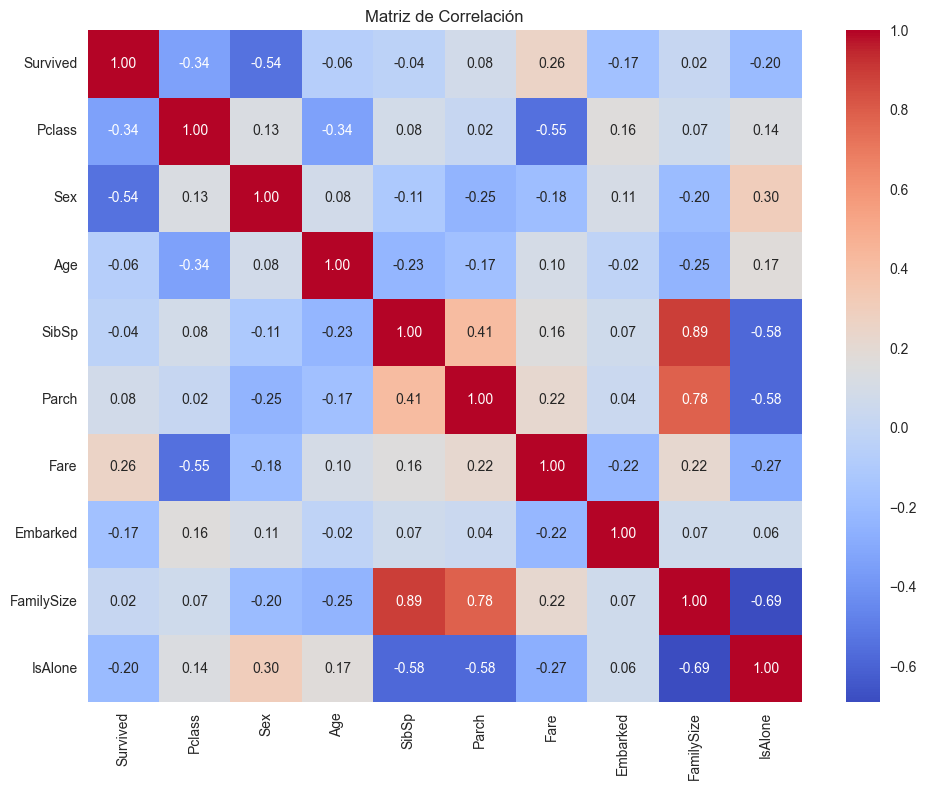

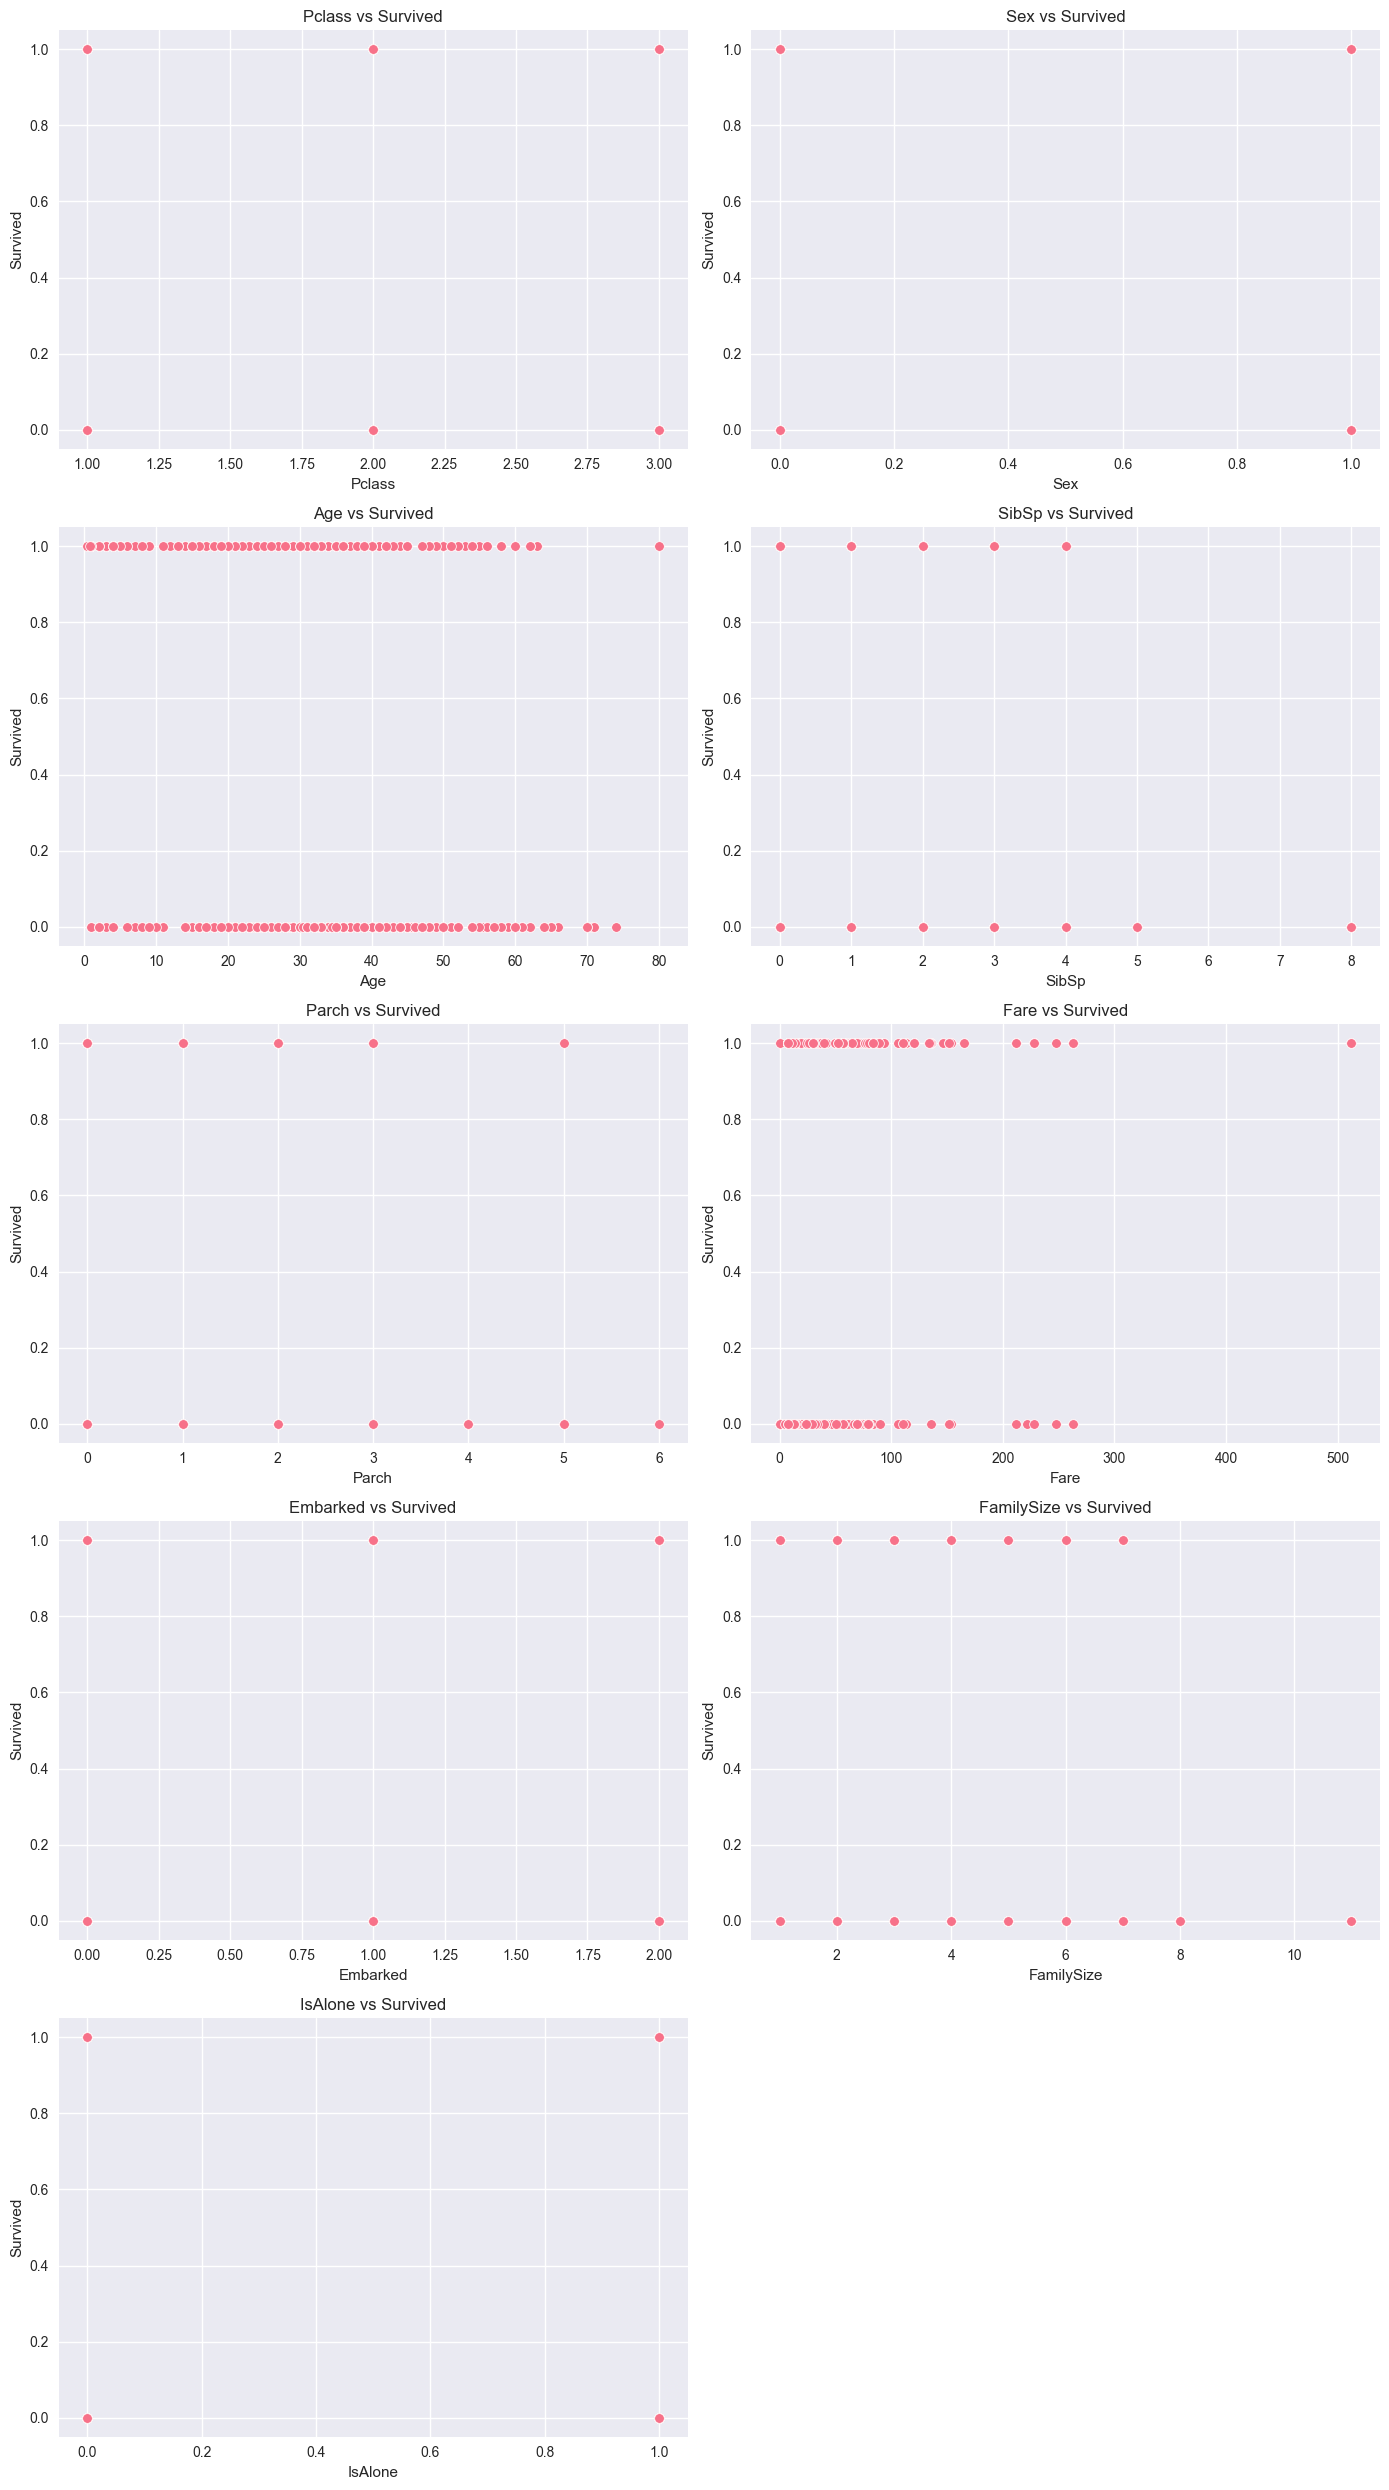

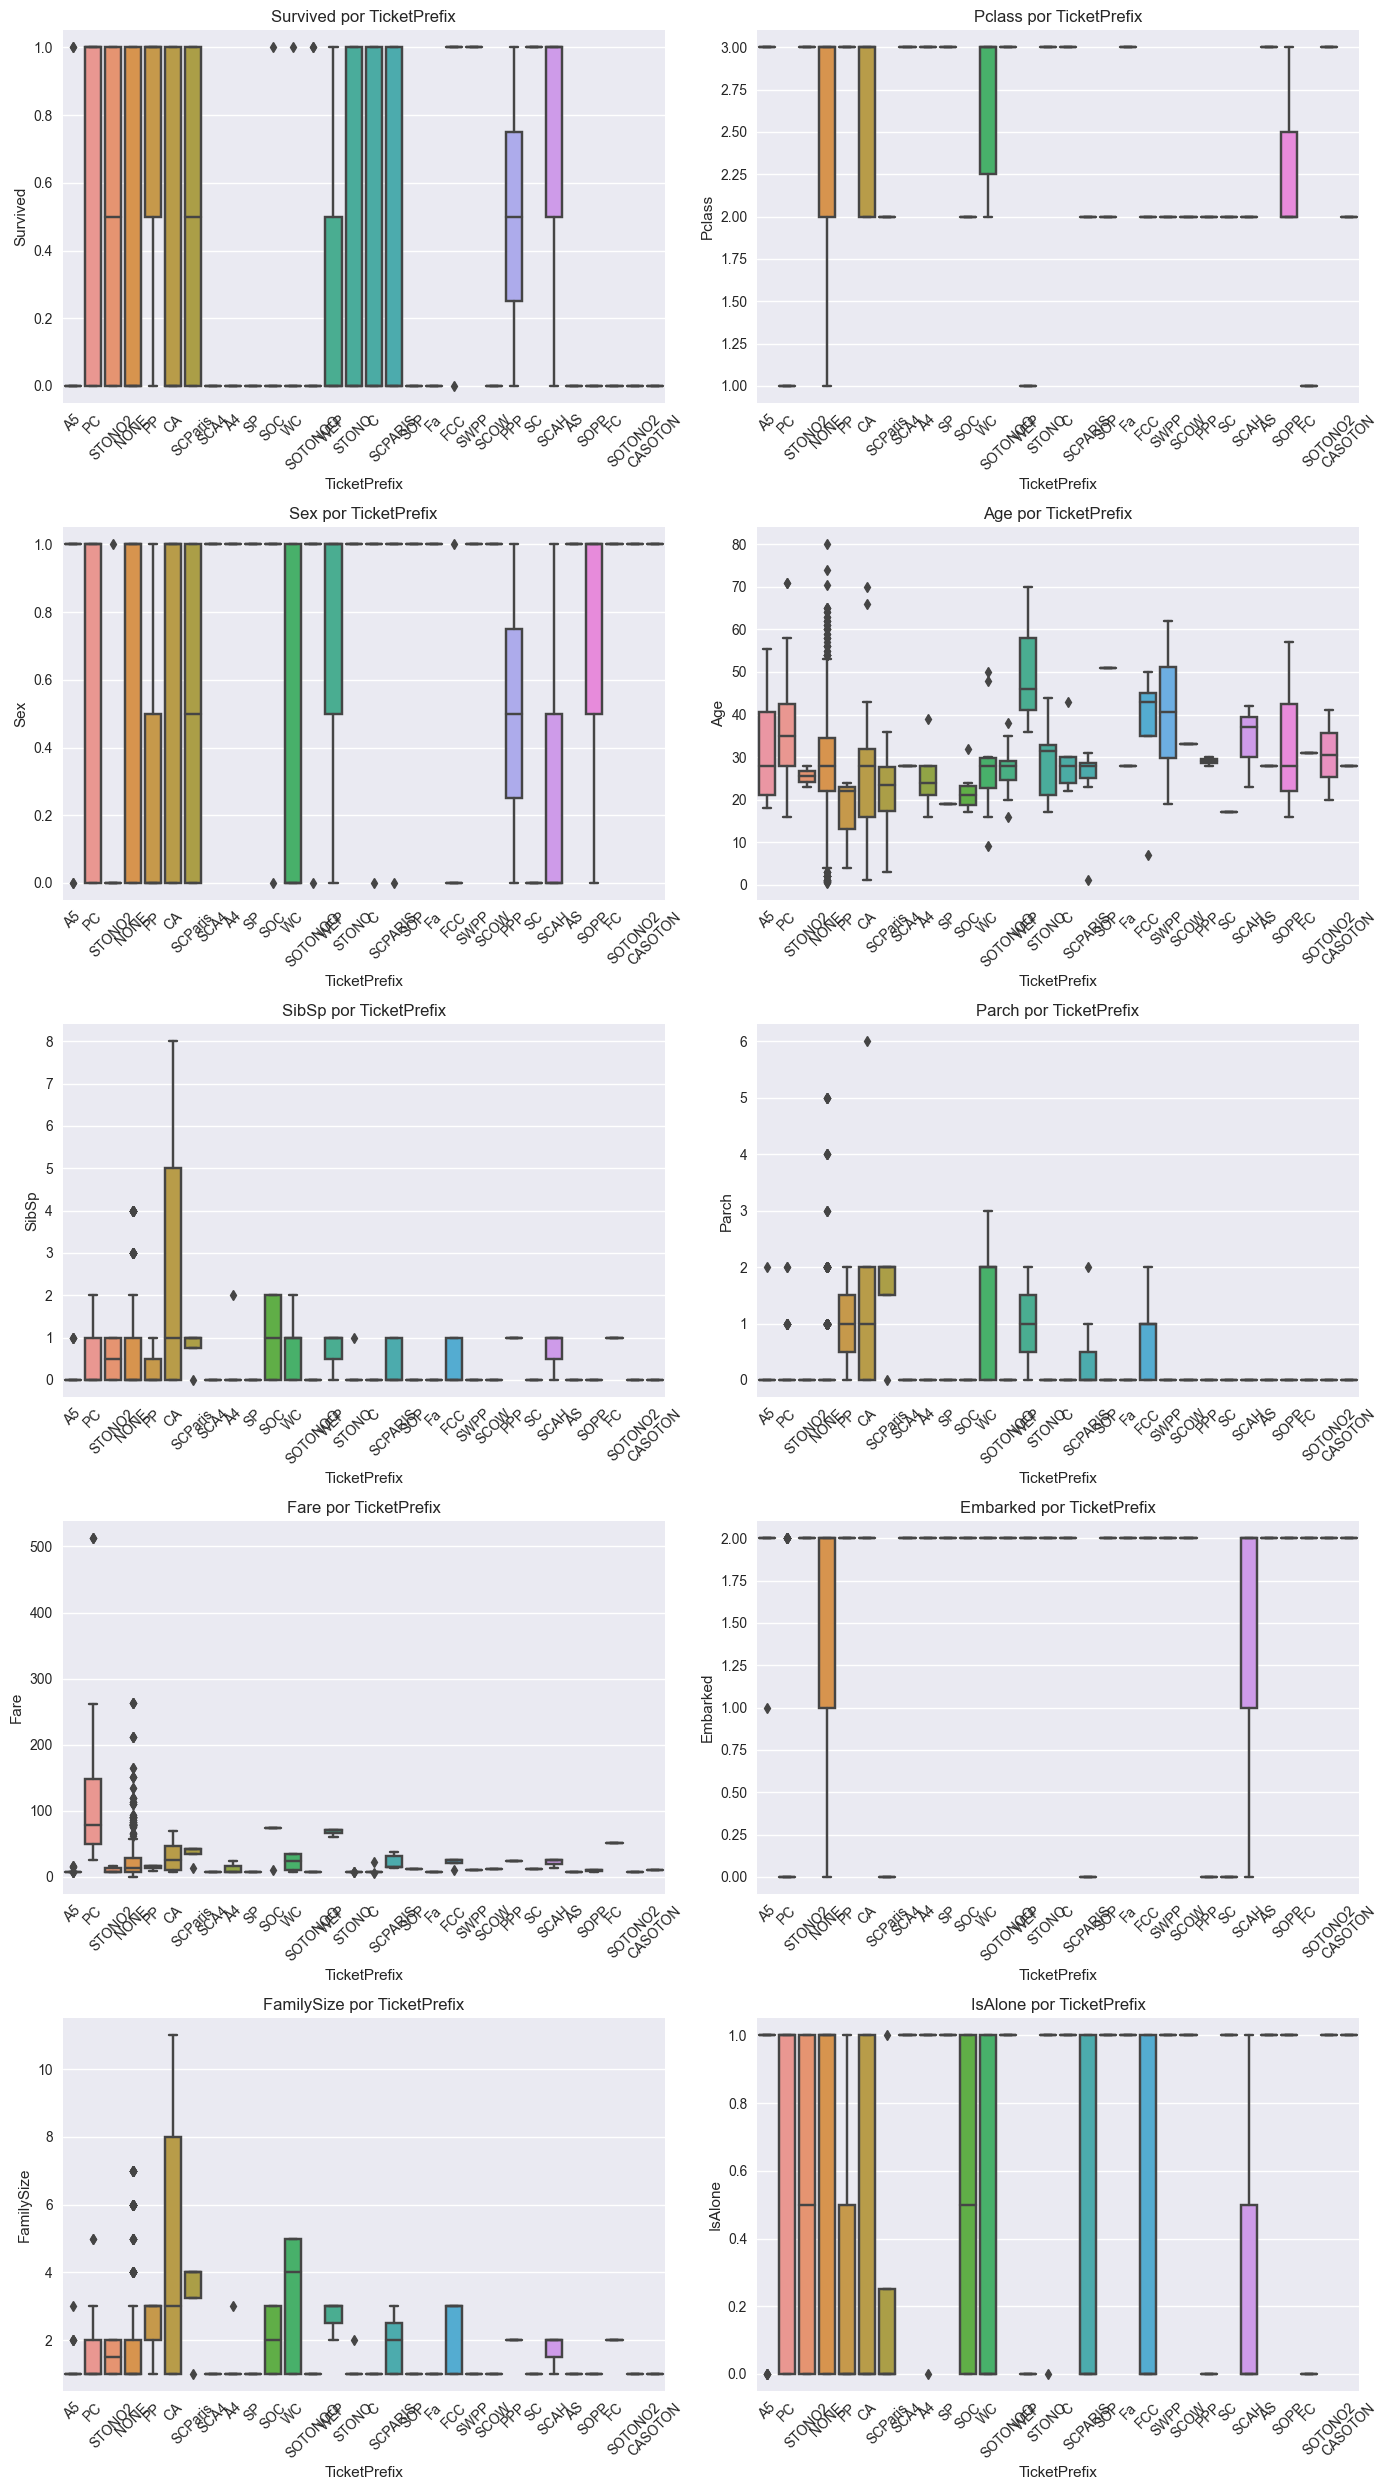

In [98]:
def bivariate_analysis(df, target=None):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import math

    categorical_vars = df.select_dtypes(include=['object', 'category', 'bool']).columns
    numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns

    print("=== Correlación Numérica ===")
    corr_matrix = df[numerical_vars].corr()
    print(corr_matrix)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlación')
    plt.tight_layout()
    plt.show()

    # 2. Numérico vs Target numérico → scatterplots
    if target and target in numerical_vars:
        cols = [col for col in numerical_vars if col != target]
        n = len(cols)
        ncols = 2
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
        axes = axes.flatten()

        for i, col in enumerate(cols):
            sns.scatterplot(x=df[col], y=df[target], ax=axes[i])
            axes[i].set_title(f'{col} vs {target}')

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    # 3. Categórico vs Numérico → boxplots
    boxplots = []
    for cat in categorical_vars:
        for num in numerical_vars:
            boxplots.append((cat, num))

    n = len(boxplots)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = axes.flatten()

    for i, (cat, num) in enumerate(boxplots):
        sns.boxplot(x=cat, y=num, data=df, ax=axes[i])
        axes[i].set_title(f'{num} por {cat}')
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # 4. Categórico vs Categórico → heatmaps de tablas de contingencia
    heatmaps = []
    for i, cat1 in enumerate(categorical_vars):
        for cat2 in categorical_vars[i + 1:]:
            heatmaps.append((cat1, cat2))

    if heatmaps:
        n = len(heatmaps)
        ncols = 2
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
        axes = axes.flatten()

        for i, (cat1, cat2) in enumerate(heatmaps):
            ct = pd.crosstab(df[cat1], df[cat2])
            print(f"\nTabla de contingencia: {cat1} vs {cat2}")
            print(ct)
            sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[i])
            axes[i].set_title(f'{cat1} vs {cat2}')

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
bivariate_analysis(train_data, target='Survived')

### Entrenamiento modelos 

In [99]:

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Parámetros para GridSearch
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
}

# Modelos base
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Entrenamiento y evaluación
results = []
best_models = {}

for name, model in models.items():
    print(f"Entrenando {name}...")
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_score = grid.best_score_
    test_score = accuracy_score(y_test, best_model.predict(X_test))

    best_models[name] = best_model
    results.append({
        'Modelo': name,
        'CV Accuracy': best_score,
        'Test Accuracy': test_score,
        'Mejores Parámetros': grid.best_params_
    })

# Convertir resultados en DataFrame
results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)
print("\nResumen de Resultados:")
print(results_df)

# Mejor modelo
mejor_modelo = results_df.iloc[0]
print(f"Mejor Modelo: {mejor_modelo['Modelo']}")
print(f"Accuracy en Test: {mejor_modelo['Test Accuracy']:.4f}")

Entrenando Random Forest...
Entrenando SVM...
Entrenando KNN...
Entrenando Gradient Boosting...

Resumen de Resultados:
              Modelo  CV Accuracy  Test Accuracy  \
2                KNN     0.793559       0.837989   
1                SVM     0.822988       0.815642   
0      Random Forest     0.832828       0.810056   
3  Gradient Boosting     0.828602       0.810056   

                                  Mejores Parámetros  
2           {'n_neighbors': 5, 'weights': 'uniform'}  
1         {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}  
0  {'max_depth': 5, 'min_samples_split': 2, 'n_es...  
3  {'learning_rate': 0.05, 'max_depth': 3, 'n_est...  
Mejor Modelo: KNN
Accuracy en Test: 0.8380


Check data test

In [ ]:
test_data = pd.read_csv('titanic/test.csv')[['Pclass','Sex','Age','SibSp','Parch','Ticket','Fare','Embarked']]
test_data.drop(columns=['Ticket'], inplace=True)
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())
test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1
test_data['IsAlone'] = (test_data['FamilySize'] == 1).astype(int)
test_data['Sex'] = le_sex.fit_transform(test_data['Sex'])
test_data['Embarked'] = le_emb.fit_transform(test_data['Embarked'])
X = test_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']]
X_test_scaled = scaler.transform(X)
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1] 
results = test_data.copy()
results['Survived_Pred'] = y_pred
results['Survival_Probability'] = y_prob
results[[ 'Survived_Pred', 'Survival_Probability']].head()

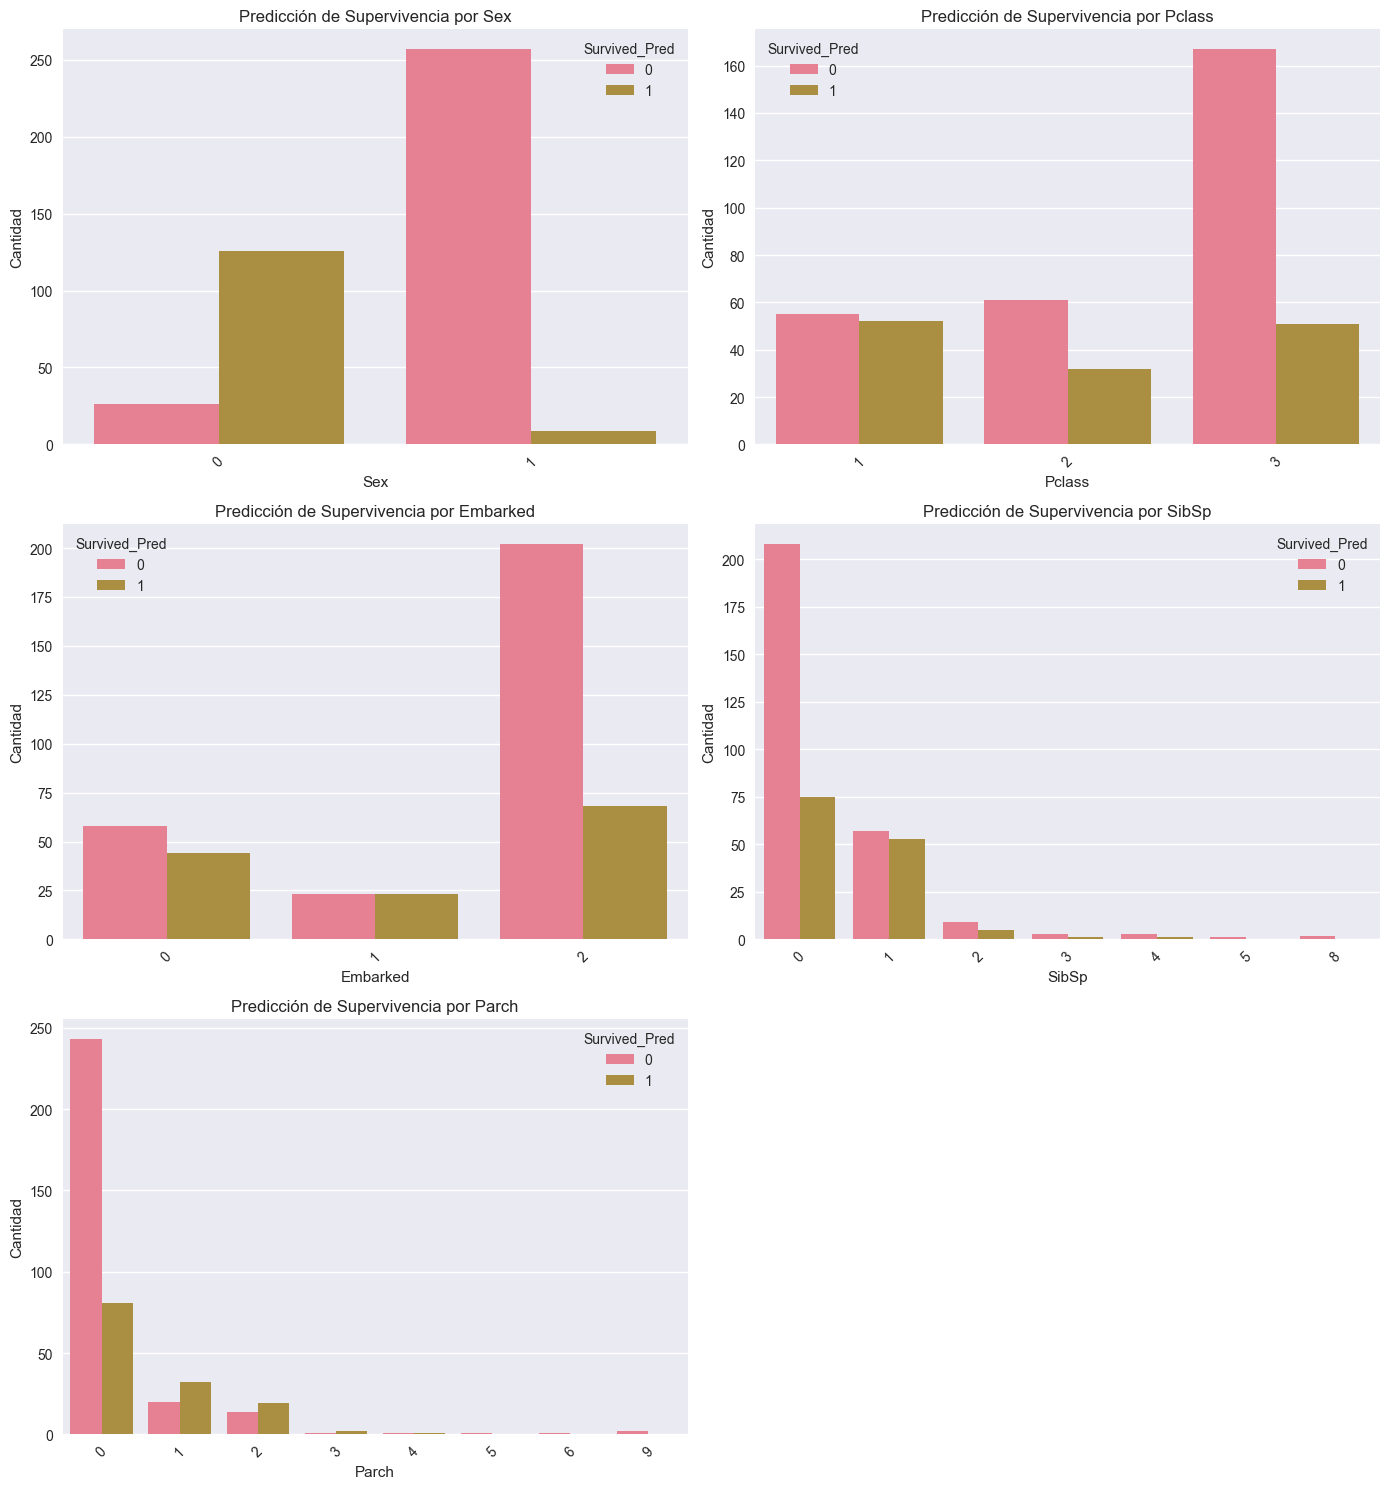

In [103]:

def plot_survival_predictions(df, target='Survived_Pred', features=None):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import math
    if features is None:
        features = ['Sex', 'Pclass', 'Embarked', 'SibSp', 'Parch']
    n = len(features)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        if df[feature].dtype in ['object', 'category'] or df[feature].nunique() <= 10:
            sns.countplot(x=feature, hue=target, data=df, ax=axes[i])
            axes[i].set_title(f'Predicción de Supervivencia por {feature}')
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('Cantidad')
            axes[i].tick_params(axis='x', rotation=45)
        else:
            sns.histplot(data=df, x=feature, hue=target, multiple='stack', ax=axes[i], bins=range(df[feature].min(), df[feature].max() + 2))
            axes[i].set_title(f'Predicción por {feature}')
            axes[i].set_xlabel(feature)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
plot_survival_predictions(results)

In [104]:
# Tasa de supervivencia predicha
survival_rate = results['Survived_Pred'].mean()
print(f"Tasa de supervivencia predicha en test: {survival_rate:.2%}")

# Conteo general
print("\nConteo de predicciones:")
print(results['Survived_Pred'].value_counts().rename(index={0: 'No', 1: 'Sí'}))

# Supervivencia por género
print("\nSupervivencia por género:")
print(results.groupby('Sex')['Survived_Pred'].value_counts(normalize=True).unstack().rename(columns={0: 'No', 1: 'Sí'}).round(2))

Tasa de supervivencia predicha en test: 32.30%

Conteo de predicciones:
Survived_Pred
No    283
Sí    135
Name: count, dtype: int64

Supervivencia por género:
Survived_Pred    No    Sí
Sex                      
0              0.17  0.83
1              0.97  0.03


In [106]:
# Crear tabla resumen de supervivencia predicha
def generar_resumen_supervivencia(df, target='Survived_Pred'):
    print(f"Tasa global de supervivencia predicha: {df[target].mean():.2%}\n")

    print("Conteo de predicciones:")
    print(df[target].value_counts().rename(index={0: 'No', 1: 'Sí'}), "\n")

    variables = ['Sex', 'Pclass', 'Embarked', 'IsAlone']

    for var in variables:
        print(f"Supervivencia por {var}:")
        tabla = pd.crosstab(df[var], df[target], normalize='index').round(2)
        tabla.columns = ['No', 'Sí']
        print(tabla, "\n")

# Ejecutar función
generar_resumen_supervivencia(results)

Tasa global de supervivencia predicha: 32.30%

Conteo de predicciones:
Survived_Pred
No    283
Sí    135
Name: count, dtype: int64 

Supervivencia por Sex:
       No    Sí
Sex            
0    0.17  0.83
1    0.97  0.03 

Supervivencia por Pclass:
          No    Sí
Pclass            
1       0.51  0.49
2       0.66  0.34
3       0.77  0.23 

Supervivencia por Embarked:
            No    Sí
Embarked            
0         0.57  0.43
1         0.50  0.50
2         0.75  0.25 

Supervivencia por IsAlone:
           No    Sí
IsAlone            
0        0.50  0.50
1        0.79  0.21 



In [109]:
results

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Survived_Pred,Survival_Probability
0,3,1,34.5,0,0,7.8292,1,1,1,0,0.123168
1,3,0,47.0,1,0,7.0000,2,2,0,1,0.625288
2,2,1,62.0,0,0,9.6875,1,1,1,0,0.102203
3,3,1,27.0,0,0,8.6625,2,1,1,0,0.133688
4,3,0,22.0,1,1,12.2875,2,3,0,0,0.474783
...,...,...,...,...,...,...,...,...,...,...,...
413,3,1,27.0,0,0,8.0500,2,1,1,0,0.133688
414,1,0,39.0,0,0,108.9000,0,1,1,1,0.953189
415,3,1,38.5,0,0,7.2500,2,1,1,0,0.106969
416,3,1,27.0,0,0,8.0500,2,1,1,0,0.133688


In [ ]:
variables = ['Sex', 'Pclass', 'Embarked', 'IsAlone']

for var in variables:
    print(f"Supervivencia por {var}:")
    tabla = pd.crosstab(results[var], results['Survived_Pred'], normalize='index').round(2)
    tabla.columns = ['No', 'Sí']
    print(tabla, "\n")


Supervivencia por Sex:
       No    Sí
Sex            
0    0.17  0.83
1    0.97  0.03 

Supervivencia por Pclass:
          No    Sí
Pclass            
1       0.51  0.49
2       0.66  0.34
3       0.77  0.23 

Supervivencia por Embarked:
            No    Sí
Embarked            
0         0.57  0.43
1         0.50  0.50
2         0.75  0.25 

Supervivencia por IsAlone:
           No    Sí
IsAlone            
0        0.50  0.50
1        0.79  0.21 

Supervivencia por Age:
         No    Sí
Age              
0.17   0.00  1.00
0.33   0.00  1.00
0.75   0.00  1.00
0.83   0.00  1.00
0.92   0.00  1.00
...     ...   ...
62.00  1.00  0.00
63.00  0.50  0.50
64.00  0.33  0.67
67.00  1.00  0.00
76.00  0.00  1.00

[79 rows x 2 columns] 



/Users/sightes/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sightes/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/sightes/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/sightes/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When gr

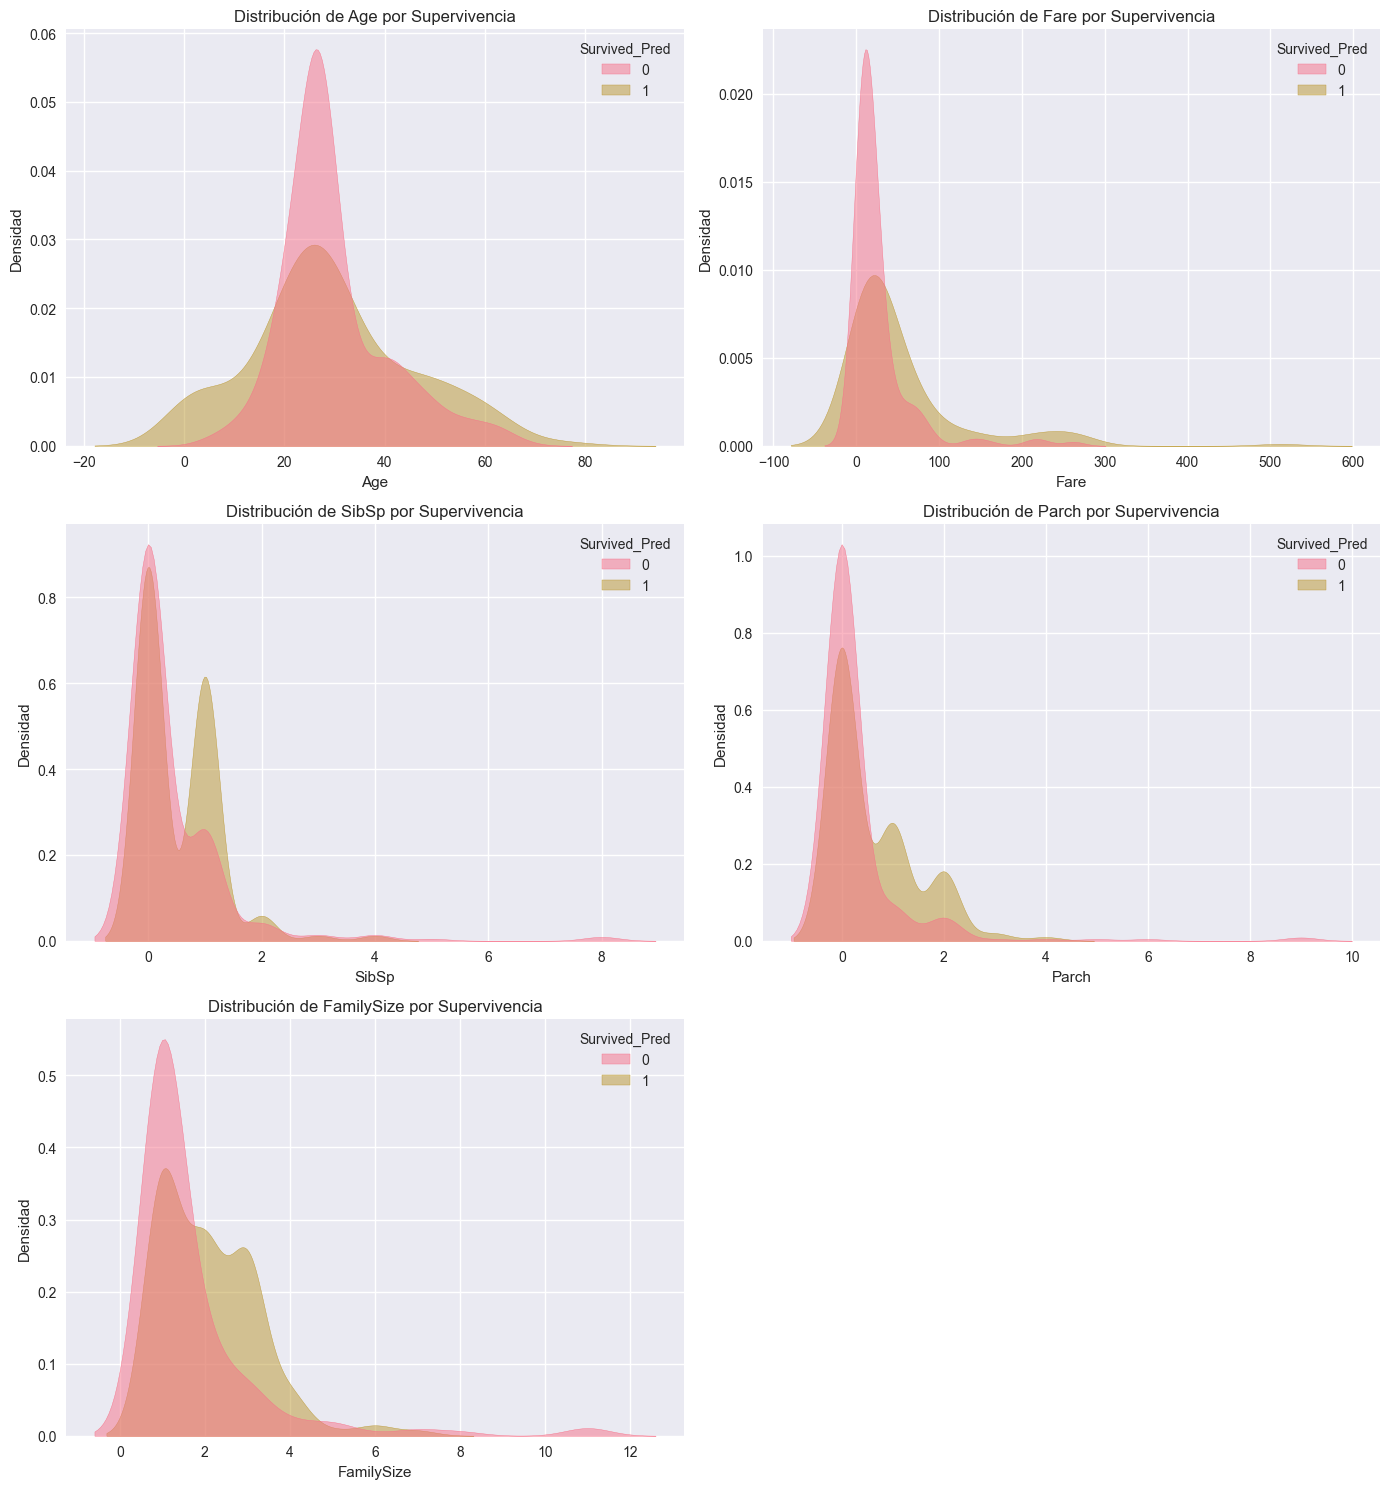

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numeric_distributions(df, numeric_vars, target='Survived_Pred'):
    n = len(numeric_vars)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(numeric_vars):
        sns.kdeplot(data=df, x=var, hue=target, fill=True, common_norm=False, alpha=0.5, ax=axes[i])
        axes[i].set_title(f'Distribución de {var} por Supervivencia')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Densidad')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])  # elimina subplots vacíos

    plt.tight_layout()
    plt.show()

# === Uso
numeric_vars = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
plot_numeric_distributions(results, numeric_vars)